<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/homework/tf-idf/1c-america-iran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [50]:

import nltk
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
!pip install Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download resource NLTK yang dibutuhkan sekali saja
nltk.download('punkt')
nltk.download('punkt_tab')

import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 2. Define Document

In [51]:
import requests
from bs4 import BeautifulSoup

# URL of the article
url = "https://www.cnnindonesia.com/internasional/20260309044622-120-1335708/tok-anak-ali-khamenei-mojtaba-khamenei-jadi-pemimpin-tertinggi-iran"

# Adding headers to mimic a browser and avoid 403 Forbidden errors
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    # Fetch the content from the URL with headers
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    html_content = response.text

    # Parse the HTML content
    soup = BeautifulSoup(html_content, 'html.parser')

    # Target the article body container
    article_body = soup.find('div', class_='detail-text')

    if article_body:
        # Extract text from paragraphs
        paragraphs = article_body.find_all('p')
        document_text = "\n".join([p.get_text() for p in paragraphs if p.get_text().strip() != ''])
        if document_text:
             print("Successfully extracted article text from the URL.")
        else:
             document_text = "Article content is empty. Check class names."
             print(document_text)
    else:
        document_text = "Article body container not found."
        print(document_text)

except requests.exceptions.RequestException as e:
    document_text = f"Error fetching URL: {e}"
    print(document_text)
except Exception as e:
    document_text = f"Error processing content: {e}"
    print(document_text)

Successfully extracted article text from the URL.


# Text Preprocessing

In [52]:
# Tokenisasi kalimat
sentences = sent_tokenize(document_text)

# Inisialisasi Sastrawi Stopword Remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Pembersihan kalimat (menghapus stopword Indonesia)
cleaned_sentences = [stopword_remover.remove(s) for s in sentences]


In [53]:
# Display a few original and cleaned sentences
print("--- Original vs. Cleaned Sentences ---")
for i in range(min(3, len(sentences))):
    print(f"Original Sentence {i+1}: {sentences[i]}")
    print(f"Cleaned Sentence {i+1}: {cleaned_sentences[i]}\n")

print(f"Total sentences tokenized: {len(sentences)}")
print(f"Total cleaned sentences: {len(cleaned_sentences)}")

--- Original vs. Cleaned Sentences ---
Original Sentence 1: Iran pada Senin menunjuk Mojtaba Khamenei sebagai pemimpin tertinggi negara tersebut menggantikan mendiang sang ayah, Ayatollah Ali Khamenei, Senin (9/3).
Cleaned Sentence 1: Iran pada Senin menunjuk Mojtaba Khamenei sebagai pemimpin tertinggi negara tersebut menggantikan mendiang sang ayah, Ayatollah Ali Khamenei, Senin (9/3).

Original Sentence 2: Penunjukan ini berlangsung sepekan lebih setelah Ali Khamenei tewas dalam serangan gabungan Amerika Serikat dan Israel pada 28 Februari lalu yang memicu perang meluas di Timur Tengah hingga hari ini.
Cleaned Sentence 2: Penunjukan berlangsung sepekan lebih Ali Khamenei tewas serangan gabungan Amerika Serikat Israel 28 Februari lalu memicu perang meluas Timur Tengah hingga hari ini.

Original Sentence 3: "Dengan suara yang menentukan, Majelis Ahli menunjuk Ayatollah Seyyed Mojtaba Hosseini Khamenei sebagai Pemimpin ketiga sistem sakral Republik Islam Iran," kata majelis tersebut dal

# TF-IDF

In [54]:
# Training TF-IDF pada kalimat yang sudah dibersihkan
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()


In [55]:
print(f"TF-IDF Feature Matrix")
print(tfidf_matrix)

print(f"TF-IDF Matrix Shape (sentences x unique words):")
print(tfidf_matrix.shape)

print(f"\nFeature Names: ")
print(feature_names)

if cleaned_sentences:
    first_cleaned_sentence_tfidf = tfidf_matrix[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(tfidf_matrix, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

TF-IDF Feature Matrix
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 171 stored elements and shape (9, 132)>
  Coords	Values
  (0, 37)	0.144116667278294
  (0, 80)	0.2102355231040525
  (0, 101)	0.4978251487054196
  (0, 74)	0.2102355231040525
  (0, 77)	0.144116667278294
  (0, 53)	0.32301640246966534
  (0, 99)	0.2489125743527098
  (0, 83)	0.18279371852695128
  (0, 118)	0.2102355231040525
  (0, 78)	0.2102355231040525
  (0, 117)	0.18279371852695128
  (0, 72)	0.2489125743527098
  (0, 66)	0.2489125743527098
  (0, 97)	0.2102355231040525
  (0, 8)	0.2102355231040525
  (0, 10)	0.2102355231040525
  (0, 6)	0.2102355231040525
  (1, 53)	0.14462627511462892
  (1, 6)	0.18826028877075382
  (1, 87)	0.18826028877075382
  (1, 15)	0.22289455385291926
  (1, 103)	0.22289455385291926
  (1, 56)	0.22289455385291926
  (1, 119)	0.22289455385291926
  (1, 104)	0.22289455385291926
  :	:
  (6, 92)	0.26087283421321306
  (6, 29)	0.26087283421321306
  (6, 124)	0.26087283421321306
  (6, 76)	0.26087283421321

# Calculate Sentence Score

In [56]:
# Variable initialization
sent_index = 0
sentence_scores = [] #

# Calculate sentence TF-IDF score
print("--- Sentence TF-IDF Scores ---")
for idx, i in enumerate(tfidf_matrix):
    sent_score = i.sum()
    sent_length = len(i.data) # Number of words with non-zero TF-IDF
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sentence_scores.append(avg_score)
    print(f"Sentence {idx+1}: TF-IDF Sum = {sent_score:.4f}, Word Count (non-zero TF-IDF) = {sent_length}, Average TF-IDF = {avg_score:.4f}")


--- Sentence TF-IDF Scores ---
Sentence 1: TF-IDF Sum = 3.9033, Word Count (non-zero TF-IDF) = 17, Average TF-IDF = 0.2296
Sentence 2: TF-IDF Sum = 4.7712, Word Count (non-zero TF-IDF) = 23, Average TF-IDF = 0.2074
Sentence 3: TF-IDF Sum = 5.0721, Word Count (non-zero TF-IDF) = 27, Average TF-IDF = 0.1879
Sentence 4: TF-IDF Sum = 5.1594, Word Count (non-zero TF-IDF) = 27, Average TF-IDF = 0.1911
Sentence 5: TF-IDF Sum = 5.0616, Word Count (non-zero TF-IDF) = 26, Average TF-IDF = 0.1947
Sentence 6: TF-IDF Sum = 3.8250, Word Count (non-zero TF-IDF) = 15, Average TF-IDF = 0.2550
Sentence 7: TF-IDF Sum = 4.2041, Word Count (non-zero TF-IDF) = 18, Average TF-IDF = 0.2336
Sentence 8: TF-IDF Sum = 3.0415, Word Count (non-zero TF-IDF) = 10, Average TF-IDF = 0.3041
Sentence 9: TF-IDF Sum = 2.8055, Word Count (non-zero TF-IDF) = 8, Average TF-IDF = 0.3507


In [57]:
print("\nList of average TF-IDF scores for each sentence:")
print(sentence_scores)


List of average TF-IDF scores for each sentence:
[np.float64(0.2296049547456544), np.float64(0.2074448843139795), np.float64(0.1878562676143835), np.float64(0.19108963940130771), np.float64(0.1946784401415085), np.float64(0.25500125317234457), np.float64(0.23355972279278742), np.float64(0.30414713420614153), np.float64(0.35068295155769497)]


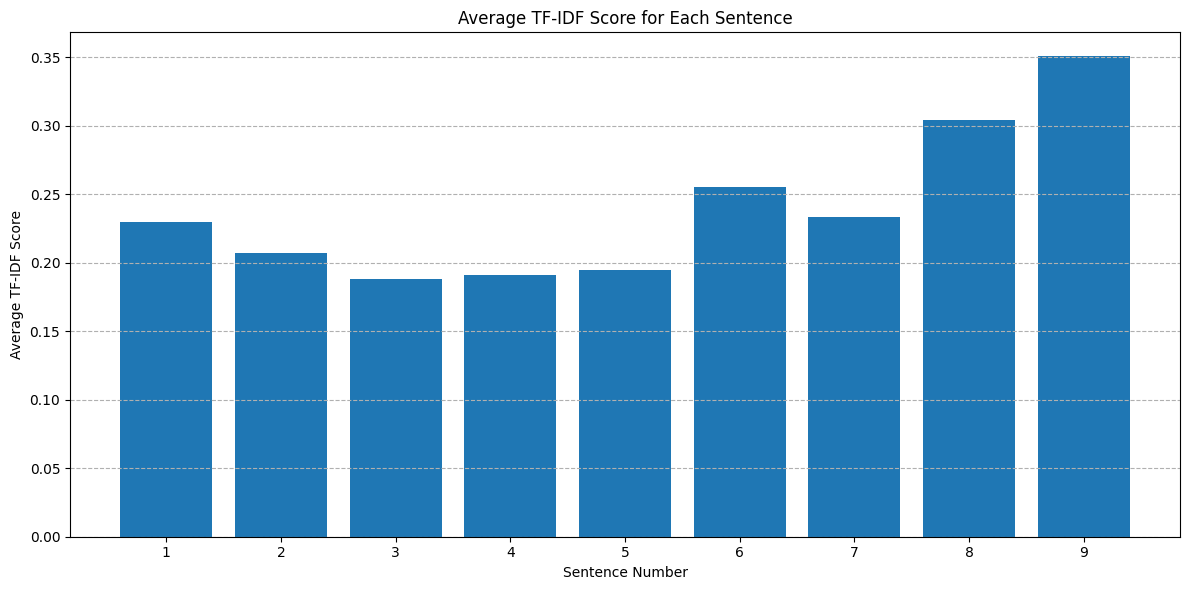

In [58]:
# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sentence_scores) + 1), sentence_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sentence_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Define Threshold

In [59]:
# Calculate the average of all sentence scores (threshold)
threshold = sum(sentence_scores) / len(sentence_scores) if sentence_scores else 0

print("\nThreshold (Average of Sentence Scores):", threshold)

# Use the cleaned_sentences from the previous step
all_cleaned_sentences = cleaned_sentences

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "world" in each sentence using the already cleaned sentences
tfidf_scores = {}
for i in range(len(sentences)): # Iterate through index
    cleaned_sentence = all_cleaned_sentences[i] # Get the pre-cleaned sentence
    tf = calculate_tf("world", cleaned_sentence)
    idf = calculate_idf("world", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "world" in each sentence
print("TF-IDF Score for 'world' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "world" across all cleaned sentences
overall_idf_investasi = calculate_idf("world", all_cleaned_sentences)
print(f"\nOverall IDF for 'world': {overall_idf_investasi:.4f}")


# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
try:
    # Reusing existing tfidf_matrix and feature_names computed in cell Cc2siGzfQKiP
    # These were already calculated on 'cleaned_sentences'.
    investasi_index = list(feature_names).index("world")
    print("\nTF-IDF Score for 'world' using TfidfVectorizer (from cleaned_sentences):")
    for i in range(len(cleaned_sentences)): # Iterate through cleaned sentences
        tfidf = tfidf_matrix[i, investasi_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'world' not found in the vocabulary after stop word removal by TfidfVectorizer.")



Threshold (Average of Sentence Scores): 0.23934058310508913
TF-IDF Score for 'world' in each cleaned sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000

Overall IDF for 'world': 0.0000

'world' not found in the vocabulary after stop word removal by TfidfVectorizer.


# Get Sentences

In [60]:
# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, score in enumerate(sentence_scores):
    if score >= threshold:
        final_summ = final_summ + " " + sentences[index]
        print(f"- {sentences[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())


**Summary Sentences (above or equal to the threshold):**
- [Gambas:Video CNN]
Posisi ini memberikan Mojtaba kewenangan terakhir dalam seluruh urusan negara di Republik Islam Iran.
- "Jika dia tidak mendapat persetujuan dari kami, dia tidak akan bertahan lama," katanya kepada ABC News.
- Israel juga mengancam akan menargetkan siapa pun yang dipilih sebagai pengganti Khamenei.

**Final Summary:**
[Gambas:Video CNN]
Posisi ini memberikan Mojtaba kewenangan terakhir dalam seluruh urusan negara di Republik Islam Iran. "Jika dia tidak mendapat persetujuan dari kami, dia tidak akan bertahan lama," katanya kepada ABC News. Israel juga mengancam akan menargetkan siapa pun yang dipilih sebagai pengganti Khamenei.


# Summarization Result

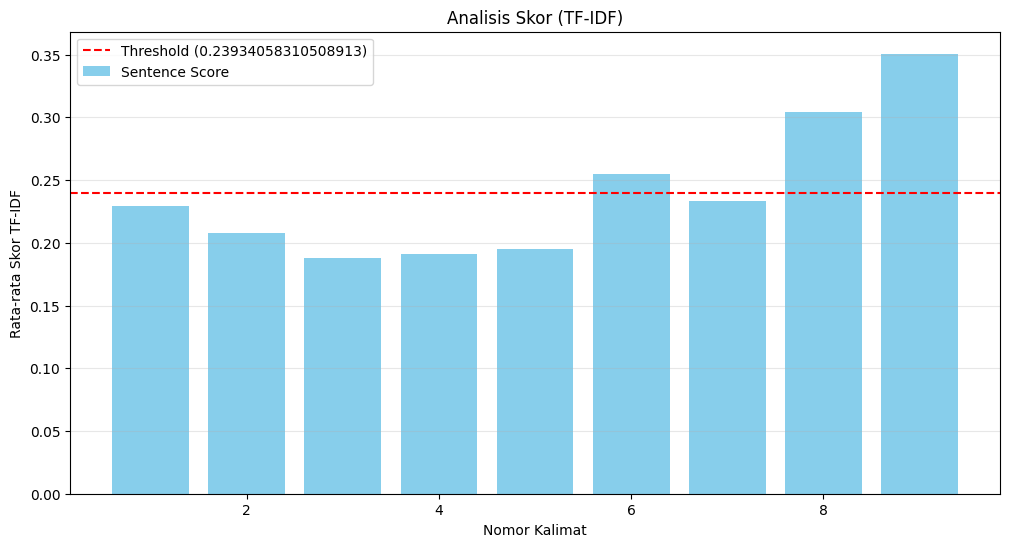


HASIL RINGKASAN AKHIR
[Gambas:Video CNN]
Posisi ini memberikan Mojtaba kewenangan terakhir dalam seluruh urusan negara di Republik Islam Iran. "Jika dia tidak mendapat persetujuan dari kami, dia tidak akan bertahan lama," katanya kepada ABC News. Israel juga mengancam akan menargetkan siapa pun yang dipilih sebagai pengganti Khamenei.


In [61]:
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sentence_scores) + 1), sentence_scores, color='skyblue', label='Sentence Score')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel("Nomor Kalimat")
plt.ylabel("Rata-rata Skor TF-IDF")
plt.title("Analisis Skor (TF-IDF)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 8. Final Output
# ==========================================
print("\n" + "="*30)
print("HASIL RINGKASAN AKHIR")
print("="*30)
print(final_summ.strip())